## Pipeline for data processing

1. clean raw tabular data
2. extract image features using Path
3. preprocess tabular data and drop Path + Frontal/Lateral
4. merge tabular + image features
5. return a model-ready matrix for clustering
6. standardize features and optionally reduce dimensionality with PCA


In [16]:
# !pip install -q transformers

import os
import numpy as np
import pandas as pd
import torch

from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, ViTModel

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

class CheXpertMultimodalPreprocessor:
    """
    End-to-end preprocessing pipeline for CheXpert multimodal clustering.

    Steps:
    1. Clean raw data
    2. Extract transformer-based image features from Path
    3. Encode tabular features
    4. Drop non-informative columns
    5. Merge tabular + image features

    Output:
        DataFrame ready for clustering
    """

    def __init__(
        self,
        base_path="/kaggle/input/chexpert",
        model_name="google/vit-base-patch16-224-in21k",
        batch_size=16,
        device=None,
    ):
        self.base_path = base_path
        self.model_name = model_name
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.processor = AutoImageProcessor.from_pretrained(self.model_name)
        self.model = ViTModel.from_pretrained(self.model_name).to(self.device)
        self.model.eval()

        self.disease_cols = [
            "Enlarged Cardiomediastinum",
            "Cardiomegaly",
            "Lung Opacity",
            "Lung Lesion",
            "Edema",
            "Consolidation",
            "Pneumonia",
            "Atelectasis",
            "Pneumothorax",
            "Pleural Effusion",
            "Pleural Other",
            "Support Devices",
        ]

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Basic cleaning:
        - remove Fracture and AP/PA
        - remove rows with No Finding == 1, then drop No Finding
        - remove age outliers
        - remove unknown Sex
        """
        df = df.copy()

        # Remove selected columns
        df = df.drop(columns=[c for c in ["Fracture", "AP/PA"] if c in df.columns], errors="ignore")

        # Remove healthy cases and then remove the column
        if "No Finding" in df.columns:
            df = df[df["No Finding"] != 1].copy()
            df = df.drop(columns=["No Finding"])

        # Clean Sex
        if "Sex" in df.columns:
            df["Sex"] = df["Sex"].astype(str).str.strip()
            df = df[~df["Sex"].str.lower().isin(["unknown", "nan", "none", ""])].copy()

        # Clean Age and remove outliers with IQR
        if "Age" in df.columns:
            df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
            df = df[df["Age"].notna()].copy()

            q1 = df["Age"].quantile(0.25)
            q3 = df["Age"].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            df = df[(df["Age"] >= lower) & (df["Age"] <= upper)].copy()

        return df.reset_index(drop=True)

    def _build_full_path(self, p: str) -> str:
        if os.path.isabs(p):
            return p
        return os.path.join(self.base_path, p)

    def extract_image_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extract ViT embeddings from image paths.
        Returns a dataframe with Path + vit feature columns.
        """
        if "Path" not in df.columns:
            raise ValueError("Path column is required for image feature extraction.")

        image_paths = [self._build_full_path(p) for p in df["Path"].tolist()]

        all_features = []
        kept_paths = []

        for start in tqdm(range(0, len(image_paths), self.batch_size), desc="Extracting image features"):
            batch_paths = image_paths[start:start + self.batch_size]

            images = []
            batch_kept_paths = []

            for img_path in batch_paths:
                try:
                    img = Image.open(img_path).convert("RGB")
                    images.append(img)
                    batch_kept_paths.append(img_path)
                except Exception as e:
                    print(f"Skipping {img_path}: {e}")

            if not images:
                continue

            inputs = self.processor(images=images, return_tensors="pt")
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)

                if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                    feats = outputs.pooler_output
                else:
                    feats = outputs.last_hidden_state[:, 0, :]

            feats = feats.cpu().numpy()
            all_features.append(feats)
            kept_paths.extend(batch_kept_paths)

        if not all_features:
            raise ValueError("No image features extracted. Check your paths.")

        all_features = np.vstack(all_features)
        feature_cols = [f"img_feat_{i}" for i in range(all_features.shape[1])]

        features_df = pd.DataFrame(all_features, columns=feature_cols)
        features_df.insert(0, "Path_full", kept_paths)

        return features_df

    def preprocess_tabular(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Encode Sex and disease labels, keep Path for merging.
        Drops Path and Frontal/Lateral from model features later.
        """
        df = df.copy()

        # Keep an absolute path column for merging with extracted image features
        df["Path_full"] = df["Path"].apply(self._build_full_path)

        # One-hot encode Sex
        if "Sex" in df.columns:
            df = pd.get_dummies(df, columns=["Sex"], prefix="Sex")

        # Encode disease columns
        for col in self.disease_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                # Standardized uncertainty handling for clustering
                df[col] = df[col].replace(-1, 0.5)
                df[col] = df[col].fillna(0)

        # Remove non-clinical / technical columns from final tabular features
        df = df.drop(columns=[c for c in ["Path", "Frontal/Lateral"] if c in df.columns], errors="ignore")

        return df

    def merge_multimodal(self, tabular_df: pd.DataFrame, image_df: pd.DataFrame) -> pd.DataFrame:
        """
        Merge tabular and image features on full path.
        """
        merged = tabular_df.merge(image_df, on="Path_full", how="inner")
        merged = merged.drop(columns=["Path_full"], errors="ignore")
        return merged

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Full pipeline on one dataframe.
        """
        clean_df = self.clean_data(df)
        image_features = self.extract_image_features(clean_df)
        tabular_features = self.preprocess_tabular(clean_df)
        multimodal_df = self.merge_multimodal(tabular_features, image_features)
        return multimodal_df

    def prepare_for_clustering(
        self,
        multimodal_df: pd.DataFrame,
        use_pca: bool = True,
        n_pca_components: int = 50,
        fit: bool = True
        ):
        """
        Prepare multimodal features for clustering.
    
        Steps:
        - ensure numeric values
        - fill missing values
        - standardize features
        - optionally apply PCA
    
        Parameters:
            multimodal_df: output of fit_transform()
            use_pca: whether to apply PCA
            n_pca_components: number of PCA components
            fit: True for train data, False for validation/test data
    
        Returns:
            X_processed: numpy array ready for clustering
        """
    
        X = multimodal_df.copy()
        X = X.apply(pd.to_numeric, errors="coerce")
        X = X.fillna(0)
    
        if fit:
            steps = [("scaler", StandardScaler())]
    
            if use_pca:
                steps.append((
                    "pca",
                    PCA(
                        n_components=n_pca_components,
                        random_state=42
                    )
                ))
    
            self.clustering_preprocessor = Pipeline(steps)
            X_processed = self.clustering_preprocessor.fit_transform(X)
    
        else:
            if not hasattr(self, "clustering_preprocessor"):
                raise ValueError(
                    "Clustering preprocessor was not fitted. "
                    "Call prepare_for_clustering(..., fit=True) first."
                )
    
            X_processed = self.clustering_preprocessor.transform(X)
    
        return X_processed

In [17]:
train_df = pd.read_csv("/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/train.csv")
# valid_df = pd.read_csv("/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/valid.csv")

train_df = train_df.sample(n=20000, random_state=42).reset_index(drop=True)
# valid_df = valid_df.sample(n=min(500, len(valid_df)), random_state=42).reset_index(drop=True)

pipeline = CheXpertMultimodalPreprocessor(
    base_path="/kaggle/input/datasets/mimsadiislam/chexpert",
    model_name="google/vit-base-patch16-224-in21k",
    batch_size=4
)

train_multimodal = pipeline.fit_transform(train_df)
# valid_multimodal = pipeline.fit_transform(valid_df)

X_train = pipeline.prepare_for_clustering(
    train_multimodal,
    use_pca=True,
    n_pca_components=50,
    fit=True
)

# X_valid = pipeline.prepare_for_clustering(
#     valid_multimodal,
#     use_pca=True,
#     fit=False
# )

print("Train clustering shape:", X_train.shape)
# print("Valid clustering shape:", X_valid.shape)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Extracting image features:   0%|          | 0/4508 [00:00<?, ?it/s]

Train clustering shape: (18030, 50)


# Evaluation:
- silhouette
- davies bouldin
- calinski harabasz

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


def evaluate_clustering(X, labels, algorithm_name):
    """
    Computes clustering metrics.
    Noise points from HDBSCAN are ignored for silhouette/DB/CH scores.
    """

    labels = np.array(labels)

    # Ignore HDBSCAN noise label = -1
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    n_clusters = len(set(labels_eval))

    if n_clusters < 2:
        return {
            "algorithm": algorithm_name,
            "n_clusters": n_clusters,
            "noise_points": np.sum(labels == -1),
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "algorithm": algorithm_name,
        "n_clusters": n_clusters,
        "noise_points": np.sum(labels == -1),
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval)
    }

Apply clustering models
- K-means
- HDBSCAN
-  Hierarchical Clustering

### Find best K
- Elbow

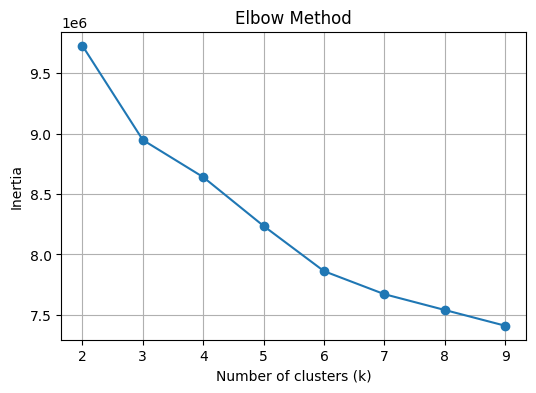

[9727839.674461486,
 8947697.827525724,
 8640389.015167046,
 8236098.499651985,
 7862001.38770159,
 7671414.7927192785,
 7540579.639353601,
 7410246.475106427]

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def elbow_method(X, k_range=range(2, 11)):
    inertia = []

    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init="auto"
        )
        kmeans.fit(X)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(list(k_range), inertia, marker='o')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.grid(True)
    plt.show()

    return inertia

elbow_method(X_train, k_range=range(2, 10))

From this elbow plot, the best choice is probably k = 3.

The biggest drop in inertia happens from k = 2 to k = 3. After k = 3, the curve continues decreasing, but the improvement becomes more gradual. That means adding more clusters after 3 gives smaller gains compared with the first major improvement.

# Find K for HC
- Look for large vertical gaps
- Cut the tree where the jump is biggest

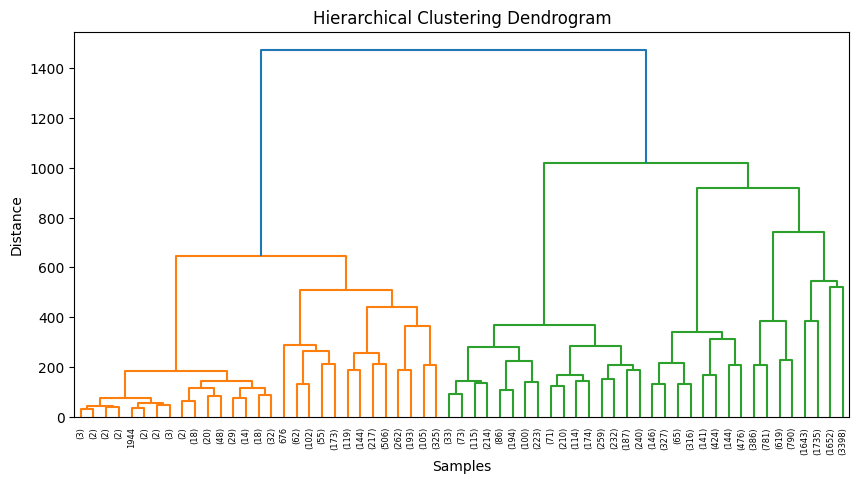

array([[6.54000000e+02, 9.45100000e+03, 0.00000000e+00, 2.00000000e+00],
       [1.25150000e+04, 1.60960000e+04, 9.77446603e+00, 2.00000000e+00],
       [1.13590000e+04, 1.37780000e+04, 9.84752121e+00, 2.00000000e+00],
       ...,
       [3.60430000e+04, 3.60550000e+04, 9.18567353e+02, 1.30430000e+04],
       [3.60460000e+04, 3.60560000e+04, 1.01974384e+03, 1.55680000e+04],
       [3.60540000e+04, 3.60570000e+04, 1.47190837e+03, 1.80300000e+04]])

In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

def plot_dendrogram(X, method="ward"):
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode="level", p=5)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

    return Z

plot_dendrogram(X_train)

For this Hierarchical Clustering dendrogram, the best number of clusters is also likely k = 3.

Why:

The dendrogram shows three large branches before the final high-level merges:

- Left orange group
- Middle green group
- Right red group

These three groups remain separated until relatively large distances, so cutting the dendrogram around distance 250–300 gives approximately 3 clusters.

In [28]:
from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan

results = []
clustered_outputs = {}

# K-Means
k = 3
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

labels = kmeans.fit_predict(X_train)

clustered_df = train_multimodal.copy()
clustered_df["cluster"] = labels

name = f"KMeans_k={k}"
clustered_outputs[name] = clustered_df
results.append(evaluate_clustering(X_train, labels, name))



hdb = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=1,
    metric="euclidean"
)

labels = hdb.fit_predict(X_train)

clustered_df = train_multimodal.copy()
clustered_df["cluster"] = labels

name = f"HDBSCAN_min_cluster_size={1}"
clustered_outputs[name] = clustered_df
results.append(evaluate_clustering(X_train, labels, name))


# Hierarchical Clustering
hc = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

labels = hc.fit_predict(X_train)

clustered_df = train_multimodal.copy()
clustered_df["cluster"] = labels

name = f"HC_k={k}"
clustered_outputs[name] = clustered_df
results.append(evaluate_clustering(X_train, labels, name))

## Compare results

In [29]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="silhouette",
    ascending=False
)

results_df

,algorithm,n_clusters,noise_points,silhouette,davies_bouldin,calinski_harabasz
1,HDBSCAN_min_cluster_size=1,2,3068,0.213060,1.725275,1255.163236
2,HC_k=3,3,0,0.101817,2.519509,1556.948322
0,KMeans_k=3,3,0,0.097894,2.604633,1950.978132


- **Silhouette Scor**e (Higher is better, range [-1, 1]): Measures how similar an object is to its own cluster compared to others. HDBSCAN achieves the highest score (0.213), indicating its clusters are the most distinct. Both HC (0.102) and KMeans (0.098) show significantly lower scores, suggesting highly overlapping or poorly separated clusters in the latent space.

- **Davies-Bouldin Index** (Lower is better): Measures the average similarity ratio of each cluster with its most similar cluster. Again, HDBSCAN performs best (1.725), followed by HC (2.520) and K-Means (2.605).

- **Calinski-Harabasz Index** (Higher is better): Evaluates the ratio of between-cluster dispersion to within-cluster dispersion. K-Means performs the best here (1950.98), which is expected since K-Means directly optimizes for spherical variance and tends to score artificially high on this specific metric.

- **Noise Points:** This is a crucial differentiator. HDBSCAN identified 2 clusters but classified 3,068 data points as noise (outliers). In contrast, HC and K-Means were forced to assign every single data point into one of 3 clusters (0 noise points).

## Select best clustering result

In [30]:
best_algorithm = results_df.iloc[0]["algorithm"]

best_clustered_df = clustered_outputs[best_algorithm]

print("Best algorithm:", best_algorithm)
print(best_clustered_df["cluster"].value_counts())

best_clustered_df.head()

Best algorithm: HDBSCAN_min_cluster_size=1
cluster
 1    13888
-1     3068
 0     1074
Name: count, dtype: int64


,Age,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,...,img_feat_759,img_feat_760,img_feat_761,img_feat_762,img_feat_763,img_feat_764,img_feat_765,img_feat_766,img_feat_767,cluster
0,90,0.0,1.0,0.0,0.0,1.0,0.5,0.0,1.0,0.0,...,0.501565,-0.261828,-0.205402,0.488254,-0.154683,-0.090844,0.770409,0.124163,0.142207,1
1,39,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.631106,-0.403879,-0.245984,0.434693,-0.254657,-0.249220,0.713486,-0.081847,0.384167,-1
2,60,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.587248,-0.199666,-0.191408,0.438219,-0.198535,0.076385,0.739475,0.210542,0.109342,1
3,66,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.5,0.0,...,0.541567,-0.185987,-0.131090,0.433694,-0.152220,-0.085445,0.711005,0.122026,-0.020459,1
4,76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.559811,-0.201304,-0.212335,0.455548,-0.263047,-0.156303,0.660273,0.026728,0.302847,-1


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


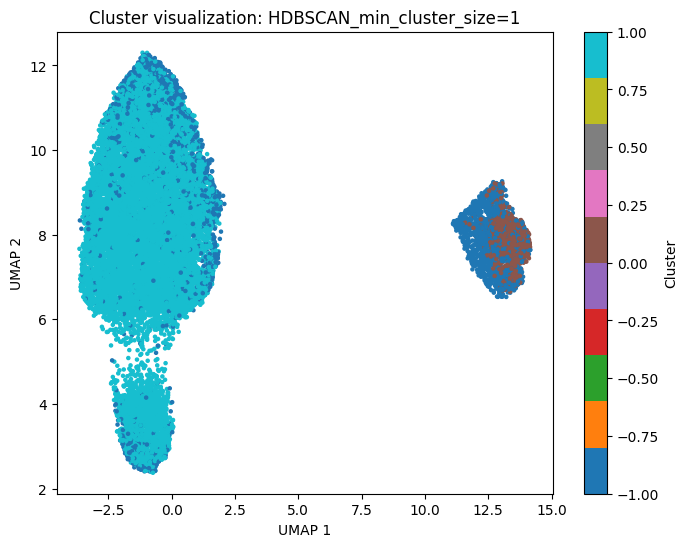

In [31]:
# !pip install -q umap-learn

import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=best_clustered_df["cluster"],
    s=5,
    cmap="tab10"
)
plt.title(f"Cluster visualization: {best_algorithm}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Cluster")
plt.show()

# T-SNE visualization

In [32]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan

def fit_all_clusterings(X, k=3, hdbscan_min_cluster_size=20, hdbscan_min_samples=1):
    """
    Fit K-Means, Hierarchical Clustering, and HDBSCAN
    and return their labels.
    """

    labels_dict = {}

    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_dict["K-Means"] = kmeans.fit_predict(X)

    # Hierarchical Clustering
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_dict["Hierarchical Clustering"] = hc.fit_predict(X)

    # HDBSCAN
    hdb = hdbscan.HDBSCAN(
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples
    )
    labels_dict["HDBSCAN"] = hdb.fit_predict(X)

    return labels_dict


labels_dict = fit_all_clusterings(
    X_train,
    k=3,
    hdbscan_min_cluster_size=20,
    hdbscan_min_samples=1
)

In [33]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def compute_tsne_embedding(X, max_samples=3000, pre_pca_components=30, random_state=42):
    """
    Compute t-SNE embedding on a subset of X for visualization.
    
    Returns:
        X_sample: sampled feature matrix
        sample_idx: indices used
        X_tsne: 2D t-SNE embedding
    """
    n_samples = X.shape[0]

    if n_samples > max_samples:
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(n_samples, size=max_samples, replace=False)
    else:
        sample_idx = np.arange(n_samples)

    X_sample = X[sample_idx]

    # Optional PCA before t-SNE for speed/stability
    if X_sample.shape[1] > pre_pca_components:
        pca = PCA(n_components=pre_pca_components, random_state=random_state)
        X_sample_reduced = pca.fit_transform(X_sample)
    else:
        X_sample_reduced = X_sample

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )

    X_tsne = tsne.fit_transform(X_sample_reduced)

    return X_sample, sample_idx, X_tsne

In [34]:
X_sample, sample_idx, X_tsne = compute_tsne_embedding(
    X_train,
    max_samples=3000,
    pre_pca_components=30
)

In [35]:
def plot_tsne_clusterings(X_tsne, labels_dict, sample_idx):
    """
    Plot one t-SNE embedding colored by labels from multiple algorithms.
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, labels) in zip(axes, labels_dict.items()):
        sampled_labels = np.array(labels)[sample_idx]

        scatter = ax.scatter(
            X_tsne[:, 0],
            X_tsne[:, 1],
            c=sampled_labels,
            s=10
        )

        ax.set_title(name)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")

        # Show number of clusters
        unique_labels = set(sampled_labels)
        n_clusters = len(unique_labels - {-1}) if -1 in unique_labels else len(unique_labels)
        ax.text(
            0.02, 0.98,
            f"Clusters: {n_clusters}",
            transform=ax.transAxes,
            verticalalignment="top"
        )

    plt.tight_layout()
    plt.show()

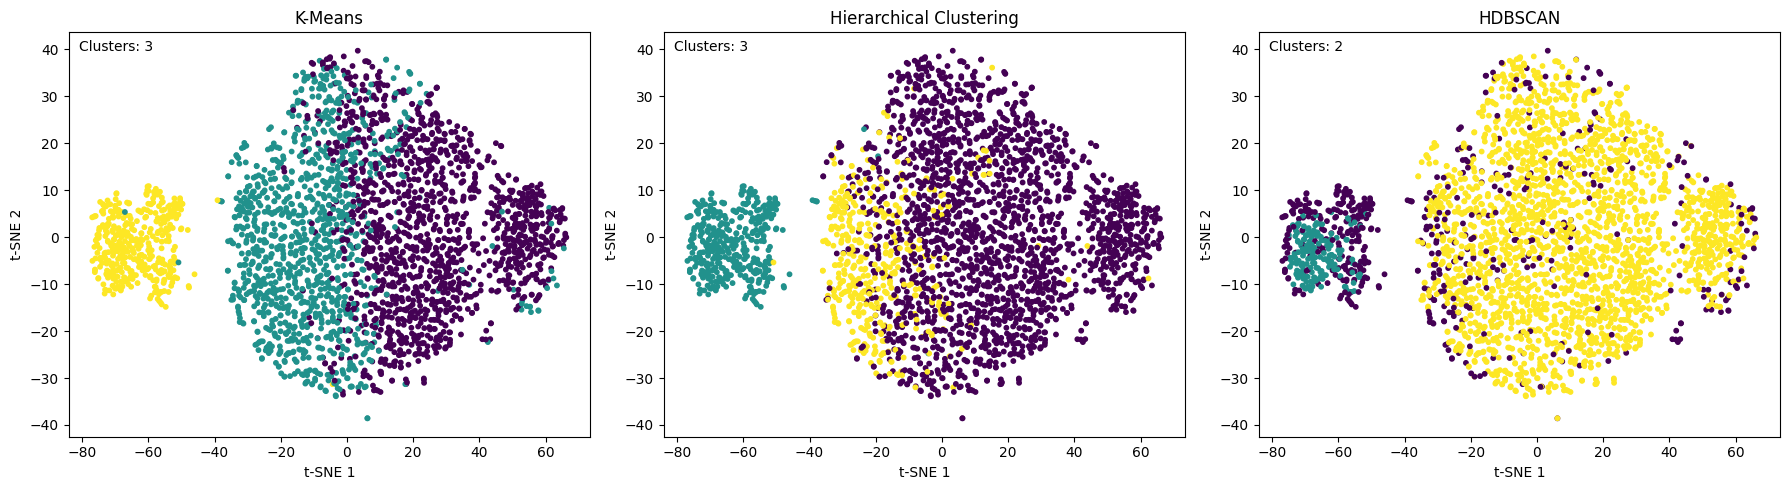

In [36]:
plot_tsne_clusterings(X_tsne, labels_dict, sample_idx)